<a href="https://colab.research.google.com/github/sanjana19991118/engineering-mindmaps-Knowledge-base/blob/main/K_Means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

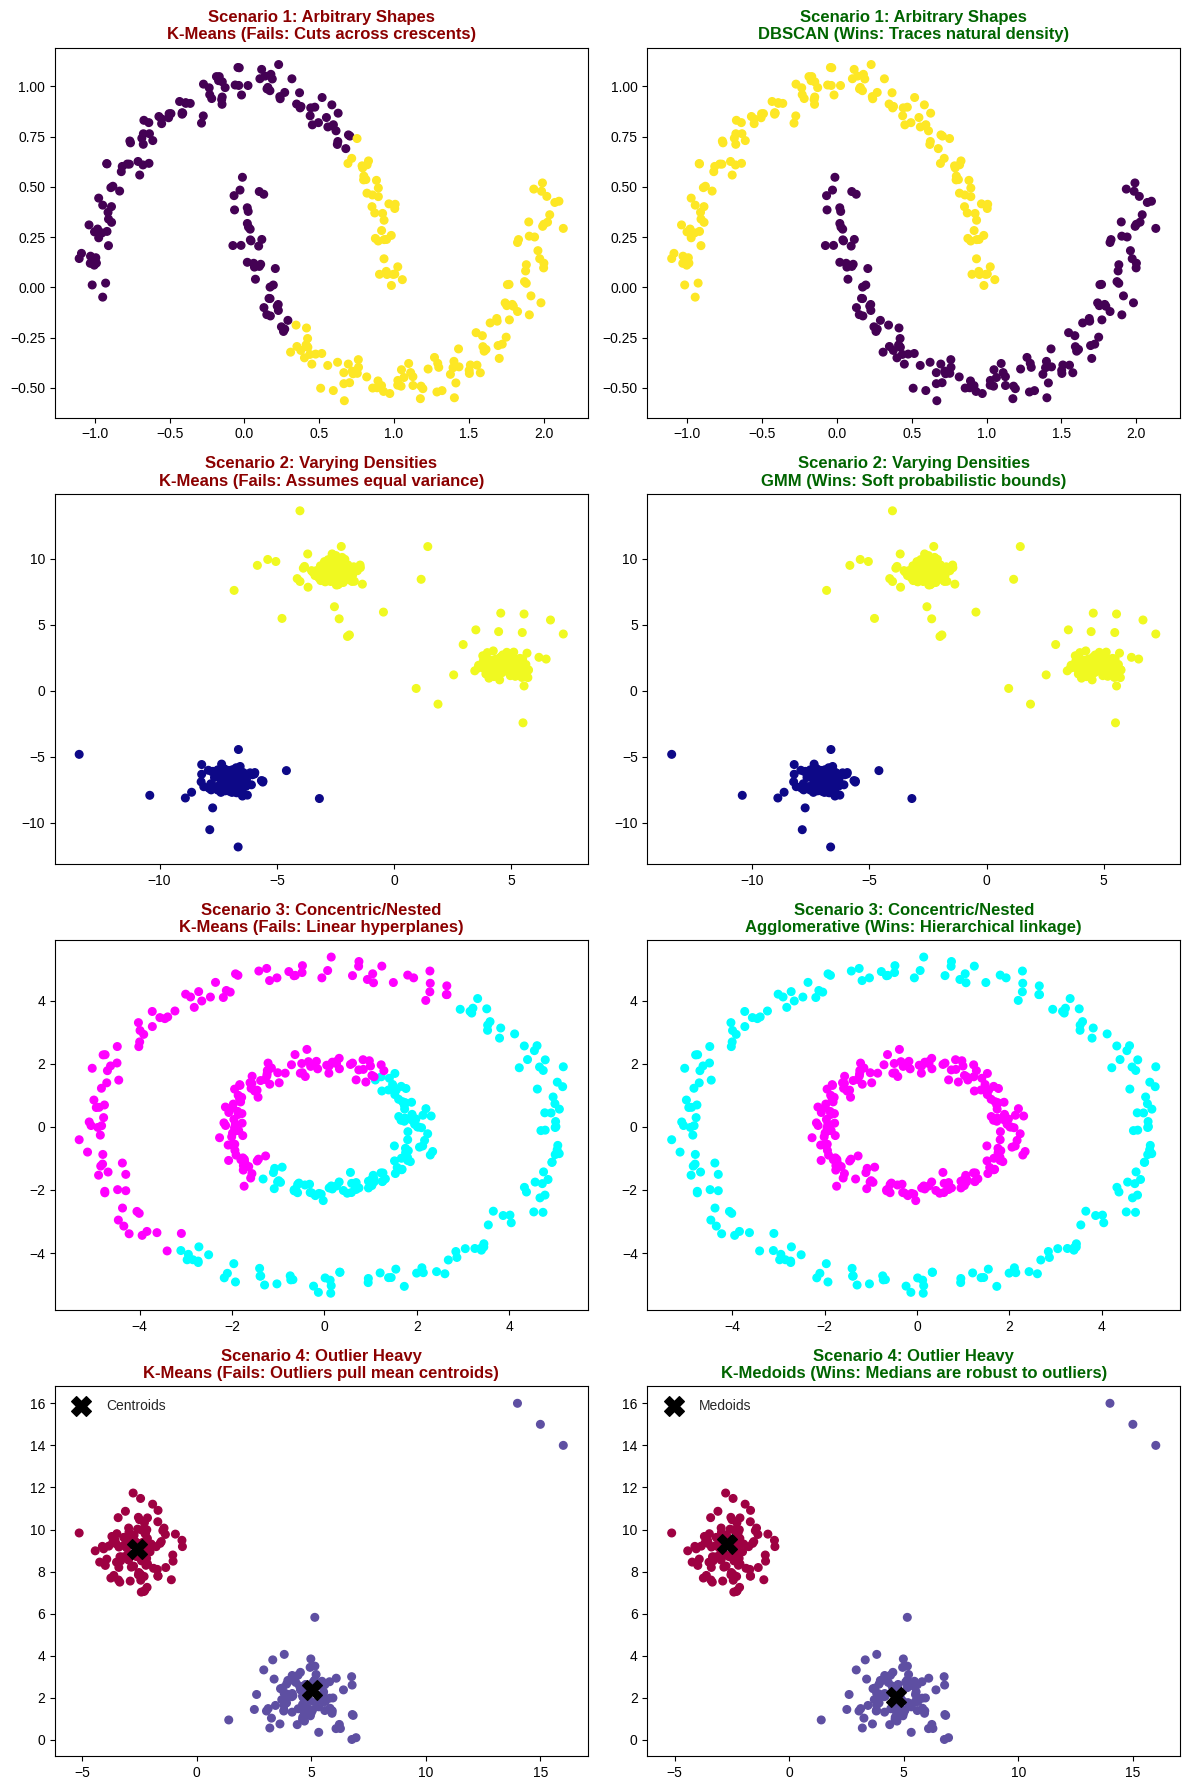

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_blobs
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn_extra.cluster import KMedoids

# Step 0: Install scikit-learn-extra for K-Medoids if not present
# Uncomment the line below if running in a fresh Colab environment:
# !pip install scikit-learn-extra

# Set up canvas for 4 scenarios x 2 algorithms (K-Means vs. Alternative)
fig, axes = plt.subplots(4, 2, figsize=(12, 18))
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# ------------------------------------------------------------------
# Scenario 1: Arbitrary Shapes (Moons) -> K-Means vs DBSCAN
# ------------------------------------------------------------------
X1, _ = make_moons(n_samples=300, noise=0.05, random_state=42)

# K-Means
kmeans1 = KMeans(n_clusters=2, random_state=42, n_init='auto').fit_predict(X1)
axes[0, 0].scatter(X1[:, 0], X1[:, 1], c=kmeans1, cmap='viridis', s=30)
axes[0, 0].set_title("Scenario 1: Arbitrary Shapes\nK-Means (Fails: Cuts across crescents)", color='darkred', fontweight='bold')

# Alternative: DBSCAN
dbscan = DBSCAN(eps=0.3, min_samples=5).fit_predict(X1)
axes[0, 1].scatter(X1[:, 0], X1[:, 1], c=dbscan, cmap='viridis', s=30)
axes[0, 1].set_title("Scenario 1: Arbitrary Shapes\nDBSCAN (Wins: Traces natural density)", color='darkgreen', fontweight='bold')

# ------------------------------------------------------------------
# Scenario 2: Varying Cluster Densities -> K-Means vs GMM
# ------------------------------------------------------------------
X2_a, _ = make_blobs(n_samples=400, cluster_std=0.5, center_box=(-10, 10), random_state=42)
X2_b, _ = make_blobs(n_samples=50, cluster_std=2.5, center_box=(-10, 10), random_state=42)
X2 = np.vstack([X2_a, X2_b])

# K-Means
kmeans2 = KMeans(n_clusters=2, random_state=42, n_init='auto').fit_predict(X2)
axes[1, 0].scatter(X2[:, 0], X2[:, 1], c=kmeans2, cmap='plasma', s=30)
axes[1, 0].set_title("Scenario 2: Varying Densities\nK-Means (Fails: Assumes equal variance)", color='darkred', fontweight='bold')

# Alternative: Gaussian Mixture Model (GMM)
gmm = GaussianMixture(n_components=2, random_state=42).fit_predict(X2)
axes[1, 1].scatter(X2[:, 0], X2[:, 1], c=gmm, cmap='plasma', s=30)
axes[1, 1].set_title("Scenario 2: Varying Densities\nGMM (Wins: Soft probabilistic bounds)", color='darkgreen', fontweight='bold')

# ------------------------------------------------------------------
# Scenario 3: Hierarchical / Nested Structures -> K-Means vs Agglomerative
# ------------------------------------------------------------------
# Creating nested concentric circles
np.random.seed(42)
r1, r2 = 2.0, 5.0
theta = np.linspace(0, 2*np.pi, 200)
inner = np.column_stack([r1*np.cos(theta), r1*np.sin(theta)]) + np.random.randn(200, 2)*0.2
outer = np.column_stack([r2*np.cos(theta), r2*np.sin(theta)]) + np.random.randn(200, 2)*0.2
X3 = np.vstack([inner, outer])

# K-Means
kmeans3 = KMeans(n_clusters=2, random_state=42, n_init='auto').fit_predict(X3)
axes[2, 0].scatter(X3[:, 0], X3[:, 1], c=kmeans3, cmap='cool', s=30)
axes[2, 0].set_title("Scenario 3: Concentric/Nested\nK-Means (Fails: Linear hyperplanes)", color='darkred', fontweight='bold')

# Alternative: Agglomerative Clustering (with single linkage for connectivity)
agg = AgglomerativeClustering(n_clusters=2, linkage='single').fit_predict(X3)
axes[2, 1].scatter(X3[:, 0], X3[:, 1], c=agg, cmap='cool', s=30)
axes[2, 1].set_title("Scenario 3: Concentric/Nested\nAgglomerative (Wins: Hierarchical linkage)", color='darkgreen', fontweight='bold')

# ------------------------------------------------------------------
# Scenario 4: Outlier-Heavy Datasets -> K-Means vs K-Medoids
# ------------------------------------------------------------------
X4_base, _ = make_blobs(n_samples=200, centers=2, cluster_std=1.0, random_state=42)
outliers = np.array([[15, 15], [16, 14], [14, 16]]) # Extreme outliers
X4 = np.vstack([X4_base, outliers])

# K-Means
kmeans4_model = KMeans(n_clusters=2, random_state=42, n_init='auto').fit(X4)
axes[3, 0].scatter(X4[:, 0], X4[:, 1], c=kmeans4_model.labels_, cmap='Spectral', s=30)
axes[3, 0].scatter(kmeans4_model.cluster_centers_[:, 0], kmeans4_model.cluster_centers_[:, 1],
                   c='black', marker='X', s=200, label='Centroids')
axes[3, 0].set_title("Scenario 4: Outlier Heavy\nK-Means (Fails: Outliers pull mean centroids)", color='darkred', fontweight='bold')
axes[3, 0].legend()

# Alternative: K-Medoids (PAM)
try:
    kmedoids = KMedoids(n_clusters=2, random_state=42).fit(X4)
    axes[3, 1].scatter(X4[:, 0], X4[:, 1], c=kmedoids.labels_, cmap='Spectral', s=30)
    axes[3, 1].scatter(kmedoids.cluster_centers_[:, 0], kmedoids.cluster_centers_[:, 1],
                       c='black', marker='X', s=200, label='Medoids')
    axes[3, 1].set_title("Scenario 4: Outlier Heavy\nK-Medoids (Wins: Medians are robust to outliers)", color='darkgreen', fontweight='bold')
    axes[3, 1].legend()
except ModuleNotFoundError:
    axes[3, 1].text(0.5, 0.5, "Please install 'scikit-learn-extra'\nto visualize K-Medoids:\n!pip install scikit-learn-extra",
                    ha='center', va='center', fontsize=12)

plt.tight_layout()
plt.show()

In [2]:
pip install scikit-learn-extra

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.0/819.0 kB 19.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-learn-extra: filename=scikit_learn_extra-0.3.0-cp313-cp313-linux_x86_64.whl size=2114458 sha256=e4291869ef3821efc50289374f780bb7d5911136da7ecf4209e68297570d2444
  Stored in directory: /root/.cache/pip/wheels/17/4b/b8/6b6711681d0981b110c9cc91ad6d1ebd88adf1547e1da301fc
Successfully built scikit-learn-extra
